# Recovering the cleavage site of internally quenched substrates

*This notebook exists in two variants that differ only in which BRENDA
extraction they read: the serum scope of the calibration manifest, and the
wider human peptidase scope audited in `0_10`. Everything else, including the
recovery rule and its validation, is identical, so the two result sets isolate
what the wider source adds.*

*Both variants are restricted to human enzymes. The kinetic entries are filtered
to Homo sapiens protein records at extraction, the EC mapping resolves through
reviewed human UniProt records, and the specificity matrix is taken from a human
MEROPS dataset. Bacterial proteases appear only in
`0_13_control_panel_labels.ipynb`, which is about the experimental control
panel and not about this calibration.*

## The problem

Every BRENDA substrate used in `2_01` is a reporter substrate: the leaving
group fixes the scissile bond at the C-terminus of the peptide, so only the
non-prime subsites carry a residue. The median substrate populates three of
eight subsites, and the prime half of every matrix is never consulted.

The database also holds 400 numeric entries on 137 internally quenched (FRET)
substrates, 6 to 17 residues long, with residues on **both** sides of the cut.
They are unusable in `2_01` for one reason: the database records the value, not
the bond that was hydrolysed.

## What cannot be done

The site cannot be read out of the database, and it must not be reconstructed
from the publications by hand into a table, because an invented label is
indistinguishable from a measured one once it is written down.

It also **must not** be assigned by picking the bond with the highest MEROPS
score and then testing whether the MEROPS score predicts the kinetics. That is
circular: the score would be built into the label it is being tested against.

## What is done instead

The unknown bond is treated as a latent variable. For a protease $\\pi$ and a
substrate $x$, every bond admissible under the protease's geometry is scored,
and the substrate is represented by the maximum:

$$S^{\\max}_{\\pi}(x) = \\max_{b \\in \\mathcal{B}(x,\\pi)} S^{M,\\mathrm{masked}}_{\\pi,b}(x)$$

This is a function of the sequence alone. No label is created, nothing is read
from a publication, and the kinetic measurement plays no part in choosing the
bond. It is also the correct model of the experiment: an internally quenched
substrate reports hydrolysis at whichever bond the enzyme prefers, so the
quantity that should predict its rate is the best available bond, not an
arbitrary one.

The bond attaining that maximum is recorded separately as the **implied site**.
It is a hypothesis carried with an explicit flag, never an observation.

## Why the maximum needs its own null

A maximum over many bonds is larger than a score at a fixed bond, and grows
with peptide length. A correlation with $S^{\\max}$ therefore cannot be compared
with one from `2_01` directly. Two controls are used:

* **length**, reported alongside every result and checked for confounding;
* **a shuffled-matrix null**, in which the residue columns of the matrix are
  permuted and the maximum is recomputed. This preserves the number of bonds,
  the peptide lengths and the shape of the maximum, and destroys only the
  specificity. Any correlation the shuffled version reaches is what the maximum
  produces by construction.

## Validating the implied site against published bonds

The implied site is a claim that can be checked, on substrates where the bond
was published. This section validates the **rule**, and it is the one place in
this notebook that reads a non-human matrix: the published bonds belong to
bacterial proteases. The substrate table built afterwards is human only. The experimental control panel provides those: `clasp-controls.tsv`
records bonds for aureolysin, V8 and LasB on LL-37 and EFK17. The rule is
scored by where the published bond ranks among the candidates, against a random
baseline of the same candidate count.

This validation is independent of the kinetics: it uses sequences and bonds
only.

## Inputs and outputs

Inputs:
`data/serum_proteolysis_calibration/processed/kinetics/brenda_serum_proteases.parquet`,
`configs/clasp-controls.tsv`, `data/merops/`,
`data/reference/human_proteome/composition.json`.

Outputs: `results/2_05_site_recovery_validation.csv`,
`results/2_06_substrate_table.csv`.

## The two substrate conventions, concretely

Almost every kinetic measurement in BRENDA was made on a **synthetic** substrate,
and synthetic substrates come in two designs that differ in exactly the property
this notebook is about. The words "reporter" and "quenched" are used throughout the
series and mean these two things.

### A reporter substrate: the bond is known, half the window is missing

```
Suc - Ala - Ala - Pro - Phe - pNA
                         ^      ^
                        P1   the reporter group
```

A chromogenic or fluorogenic leaving group sits at the C terminus. The enzyme cuts
the bond between the last peptide residue and that group, and the signal is the
released reporter.

* The **bond is known by construction**: it is the C-terminal bond. Nothing is
  inferred.
* **P1 is the last peptide residue**, and the non-prime side reaches back at most
  four residues.
* The **prime side is chemistry, not peptide**. $P_1' \ldots P_4'$ carry no residue
  and contribute nothing to the score.

`resolvable_subsites` returns $\min(\text{length},\,4)$ for such a substrate: at
best half a window, and the prime half of the matrix is never consulted.

### A quenched substrate: the window is full, the bond is unknown

```
Abz - Ala - Ala - Lys - Phe - Phe - Ser - Arg - Gln - EDDnp
donor                                                quencher
```

A fluorescence donor sits at one end and a quencher at the other, with a real
peptide between them. Cleavage **anywhere inside** separates the two and the signal
rises.

* Residues exist on **both sides** of whatever bond was cut, so all eight subsites
  can be occupied.
* But the database records the rate and **not which bond was hydrolysed**, so the
  bond is unknown.

### The trade, and why this notebook exists

| | scissile bond | window |
| --- | --- | --- |
| reporter | known by construction | at most 4 of 8 subsites, non-prime only |
| quenched | **unknown** | up to 8 of 8, both sides |

The reporter substrates that `2_01` uses never consult the prime half of any matrix
— the median reporter populates three of eight subsites. The quenched substrates are
the only ones that would, if their bond could be established, and establishing it is
the subject of this notebook.

The rule must not be "take the bond the matrix scores highest", because scoring a
bond that was chosen by the score is circular. The score of a quenched substrate is
instead the maximum over admissible bonds,
$S^{\max} = \max_b S^{M}_{\pi,b}$ — the best the protease could do with that
substrate — which uses no knowledge of the answer.

In [1]:
import re
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_AMINO_ACIDS,
    EventGeometry,
    best_merops_dataset,
    enumerate_window_scores,
    geometry_from_name,
    load_amino_acid_background,
    load_panel_metadata,
    load_protease_panel,
    masked_score_from_indices,
    merops_code_locations,
    parse_substrate,
    reporter_window_indices,
    resolvable_subsites,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
# Scope of the kinetic extraction this notebook runs on. The two variants of this
# notebook differ only in this constant and in the prefix of what they write, so
# that the effect of widening the source can be read off the two result sets.
SCOPE = "peptidase"
PREFIX = "2_06"

# Only human peptidases enter this analysis. MEROPS dataset 34 is the full human
# peptidase set and 35 its serum subset; every other dataset is a pathogen.
# REMARK: The restriction is enforced here rather than left to the EC mapping,
# which selects reviewed human UniProt records and therefore already excludes
# bacterial enzymes. Enforcing it twice means a change to the mapping cannot
# quietly bring a pathogen matrix into the substrate table.
HUMAN_MEROPS_DATASETS = (34, 35)

MIN_FRET_LENGTH = 6
N_SHUFFLES = 100
SEED = 20260920

In [3]:
human_background = load_amino_acid_background(
    common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"
)
locations = merops_code_locations(common.MEROPS_ROOT)
names = {
    entry["code"]: entry["name"]
    for entry in load_panel_metadata(list(range(36)), merops_root=common.MEROPS_ROOT)
}

panel_cache: dict[int, tuple[np.ndarray, list[str]]] = {}


def matrix_for(code: str) -> tuple[np.ndarray | None, int | None, int]:
    """Return the human specificity matrix of one MEROPS code.

    Only the human datasets are consulted, and the one holding the most cleavage
    evidence for that code is used. A code present solely in a pathogen dataset
    resolves to no matrix and its measurements are dropped.

    :param code: MEROPS peptidase code.
    :return: Tuple of the matrix ``(P, A)``, the dataset id and its cleavage
        count, or ``(None, None, 0)`` when the code has no human matrix.
    """

    entry = locations.get(code, {})
    human_entry = {
        dataset: count for dataset, count in entry.items() if dataset in HUMAN_MEROPS_DATASETS
    }
    if not human_entry:
        return None, None, 0
    dataset_id = max(human_entry, key=lambda key: human_entry[key])
    n_cleavages = human_entry[dataset_id]
    if dataset_id not in panel_cache:
        panel = load_protease_panel(
            dataset_id, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu"
        )
        panel_cache[dataset_id] = (panel.matrices.numpy().astype(np.float64), list(panel.codes))
    matrices, codes = panel_cache[dataset_id]
    return matrices[codes.index(code)], dataset_id, n_cleavages


def any_matrix_for(code: str) -> tuple[np.ndarray | None, int | None, int]:
    """Return the best-evidenced matrix of a code from any organism.

    Used **only** to validate the recovery rule against published bonds. Those
    bonds were published for bacterial proteases, so restricting this lookup to
    human datasets would leave the rule unvalidated. Validating a method on
    whatever ground truth exists is separate from choosing which enzymes enter
    the calibration, and the substrate table below uses the restricted lookup.

    :param code: MEROPS peptidase code.
    :return: Tuple of the matrix ``(P, A)``, the dataset id and its cleavage count.
    """

    dataset_id, n_cleavages = best_merops_dataset(code, locations=locations)
    if dataset_id is None:
        return None, None, 0
    if dataset_id not in panel_cache:
        panel = load_protease_panel(
            dataset_id, merops_root=common.MEROPS_ROOT, kind="logprob", device="cpu"
        )
        panel_cache[dataset_id] = (panel.matrices.numpy().astype(np.float64), list(panel.codes))
    matrices, codes = panel_cache[dataset_id]
    return matrices[codes.index(code)], dataset_id, n_cleavages


def geometry_for(code: str) -> EventGeometry:
    """Return the event geometry of a MEROPS code from its display name.

    :param code: MEROPS peptidase code.
    :return: Event geometry, defaulting to endopeptidase for unmatched names.
    """

    geometry = geometry_from_name(names.get(code, ""))
    return EventGeometry.ENDOPEPTIDASE if geometry is EventGeometry.UNKNOWN else geometry

## Ground truth: bonds published in the control panel

The control table records cleavage sites in one-based residue notation, for
example `R19|I20`, meaning the bond between residues 19 and 20. Only rows that
name a MEROPS code and give explicit bonds are usable here.

In [4]:
controls = pd.read_csv(common.ANALYSIS_ROOT / "configs" / "clasp-controls.tsv", sep="\t", dtype=str).fillna("")
BOND_PATTERN = re.compile(r"^([A-Z])(\d+)\|([A-Z])(\d+)$")

truth_rows = []
for _, row in controls.iterrows():
    sequence = row["sequence"].strip().upper()
    if not sequence or not set(sequence) <= set(MEROPS_AMINO_ACIDS):
        continue
    for code in row["merops_id"].split(";"):
        code = code.strip()
        if not code or code in {"na", "mixed"}:
            continue
        for part in row["cleavage_sites"].split(";"):
            match = BOND_PATTERN.match(part.strip())
            if match is None:
                continue
            left_residue, left_position, right_residue, right_position = match.groups()
            bond = int(left_position) - 1  # zero-based bond index
            ## The annotation carries the residues, so the mapping onto the
            ## sequence is checked rather than assumed.
            if (
                bond + 1 >= len(sequence)
                or sequence[bond] != left_residue
                or sequence[bond + 1] != right_residue
                or int(right_position) != int(left_position) + 1
            ):
                truth_rows.append(
                    {"peptide_id": row["peptide_id"], "merops_code": code, "site": part,
                     "status": "annotation_does_not_match_sequence"}
                )
                continue
            truth_rows.append(
                {
                    "peptide_id": row["peptide_id"],
                    "sequence": sequence,
                    "merops_code": code,
                    "protease": row["protease"],
                    "site": part.strip(),
                    "published_bond": bond,
                    "confidence": row["confidence"],
                    "status": "ok",
                }
            )

truth = pd.DataFrame(truth_rows)
print(f"annotated bonds parsed: {len(truth)}")
print(truth["status"].value_counts().to_string())
truth = truth.query("status == 'ok'").copy()
print()
print(f"usable published bonds: {len(truth)} on {truth['peptide_id'].nunique()} peptides "
      f"and {truth['merops_code'].nunique()} proteases")
print(truth[["peptide_id", "protease", "merops_code", "site", "confidence"]].to_string(index=False))

annotated bonds parsed: 17
status
ok    17

usable published bonds: 17 on 4 peptides and 3 proteases
peptide_id         protease merops_code    site confidence
     LL-37       aureolysin     M04.009 R19|I20       high
     LL-37       aureolysin     M04.009 R23|I24       high
     LL-37       aureolysin     M04.009 L31|V32       high
     LL-37          V8_SspA     S01.269 E16|F17       high
     LL-37 LasB_pseudolysin     M04.005 E16|F17   inferred
     LL-37 LasB_pseudolysin     M04.005 R19|I20   inferred
     LL-37 LasB_pseudolysin     M04.005 R23|I24   inferred
  LL-17-37       aureolysin     M04.009   R3|I4   inferred
  LL-17-37       aureolysin     M04.009   R7|I8   inferred
  LL-17-37       aureolysin     M04.009 L15|V16   inferred
     EFK17       aureolysin     M04.009   R4|I5       high
     EFK17       aureolysin     M04.009 D11|F12       high
     EFK17          V8_SspA     S01.269   E1|F2       high
     EFK17 LasB_pseudolysin     M04.005   E1|F2       high
     EFK17 Las

## How well does the matrix locate a published bond?

For each published bond, every admissible bond of that peptide is scored and
the published one is located in the ranking. Three numbers are reported:

* **rank** of the published bond, where 1 means the matrix put it first;
* **percentile**, the rank normalized by the number of candidates, so peptides
  of different lengths are comparable;
* **top-1** and **top-3** hit rates, against the random baselines $1/n$ and
  $3/n$ implied by the candidate count.

In [5]:
recovery_rows = []
for _, row in truth.iterrows():
    ## The published bonds are for bacterial proteases, so the rule is validated
    ## on their matrices. This is a check of the method, not a decision about
    ## which enzymes the calibration covers.
    matrix, dataset_id, n_cleavages = any_matrix_for(row["merops_code"])
    if matrix is None:
        continue
    geometry = geometry_for(row["merops_code"])
    scores, observed, admissible = enumerate_window_scores(
        row["sequence"], matrix, geometry, background=human_background
    )
    candidates = np.flatnonzero(admissible)
    if row["published_bond"] not in candidates:
        continue
    ## Rank 1 is the highest scoring candidate; ties take the average rank.
    candidate_scores = scores[candidates]
    order = (-candidate_scores).argsort()
    ranking = candidates[order]
    rank = int(np.flatnonzero(ranking == row["published_bond"])[0]) + 1
    recovery_rows.append(
        {
            "peptide_id": row["peptide_id"],
            "protease": row["protease"],
            "merops_code": row["merops_code"],
            "merops_cleavages": n_cleavages,
            "site": row["site"],
            "confidence": row["confidence"],
            "n_candidates": len(candidates),
            "published_rank": rank,
            "percentile": rank / len(candidates),
            "score_at_published": float(scores[row["published_bond"]]),
            "best_score": float(candidate_scores.max()),
        }
    )

recovery = pd.DataFrame(recovery_rows)
if recovery.empty:
    raise RuntimeError(
        "no published bond could be evaluated; the recovery rule would be unvalidated"
    )
print(recovery.round(3).to_string(index=False))
print()
print("organisms of the matrices used for this validation:")
print(recovery.groupby("merops_code")["merops_cleavages"].first().to_string())
print()
random_top1 = float((1.0 / recovery["n_candidates"]).mean())
random_top3 = float((3.0 / recovery["n_candidates"]).clip(upper=1.0).mean())
print(f"published bonds evaluated: {len(recovery)}")
print(f"top-1 hit rate: {(recovery['published_rank'] == 1).mean():.2f} "
      f"(random baseline {random_top1:.2f})")
print(f"top-3 hit rate: {(recovery['published_rank'] <= 3).mean():.2f} "
      f"(random baseline {random_top3:.2f})")
print(f"median percentile of the published bond: {recovery['percentile'].median():.2f} "
      "(0.5 would be no better than chance)")

peptide_id         protease merops_code  merops_cleavages    site confidence  n_candidates  published_rank  percentile  score_at_published  best_score
     LL-37       aureolysin     M04.009                24 R19|I20       high            36               1       0.028               4.584       4.584
     LL-37       aureolysin     M04.009                24 R23|I24       high            36               2       0.056               2.687       4.584
     LL-37       aureolysin     M04.009                24 L31|V32       high            36               5       0.139               1.660       4.584
     LL-37          V8_SspA     S01.269              4330 E16|F17       high            36               2       0.056               3.800       4.197
     LL-37 LasB_pseudolysin     M04.005                70 E16|F17   inferred            36               3       0.083               1.396       3.106
     LL-37 LasB_pseudolysin     M04.005                70 R19|I20   inferred            36    

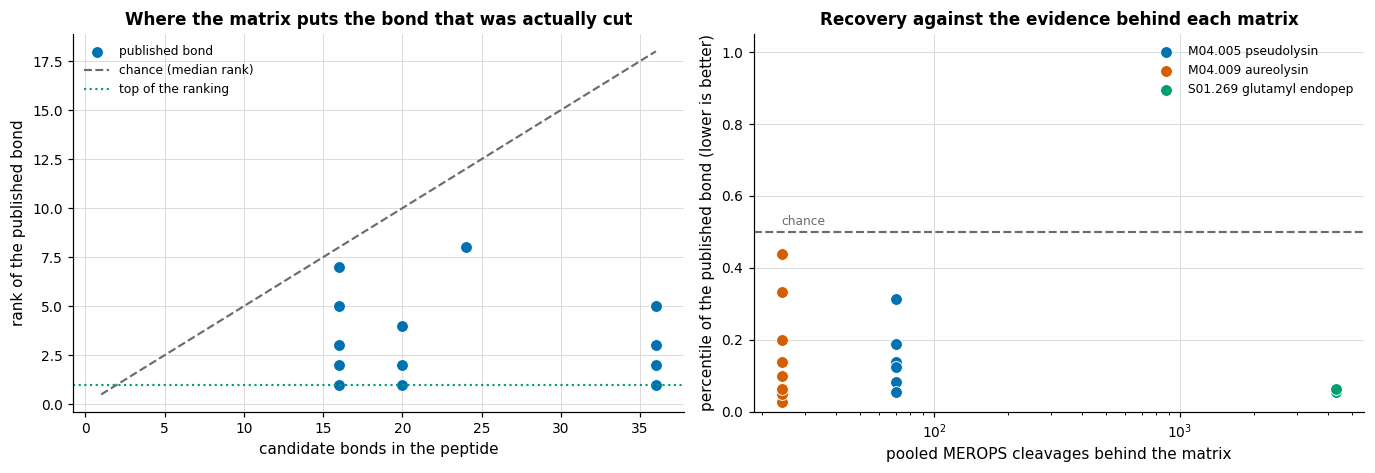

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
ax.scatter(
    recovery["n_candidates"],
    recovery["published_rank"],
    s=60,
    color=common.CATEGORICAL_COLORS[0],
    edgecolor="white",
    linewidth=0.6,
    label="published bond",
)
grid = np.arange(1, recovery["n_candidates"].max() + 1)
ax.plot(grid, grid / 2.0, color=common.NEUTRAL, linestyle="--", linewidth=1.4, label="chance (median rank)")
ax.axhline(1, color=common.CATEGORICAL_COLORS[2], linestyle=":", linewidth=1.4, label="top of the ranking")
ax.set_xlabel("candidate bonds in the peptide")
ax.set_ylabel("rank of the published bond")
ax.set_title("Where the matrix puts the bond that was actually cut")
ax.legend(fontsize=8)

ax = axes[1]
for index, code in enumerate(sorted(recovery["merops_code"].unique())):
    subset = recovery[recovery["merops_code"] == code]
    ax.scatter(
        subset["merops_cleavages"],
        subset["percentile"],
        s=60,
        color=common.CATEGORICAL_COLORS[index % len(common.CATEGORICAL_COLORS)],
        edgecolor="white",
        linewidth=0.6,
        label=f"{code} {names.get(code, '')[:16]}",
    )
ax.axhline(0.5, color=common.NEUTRAL, linestyle="--", linewidth=1.4)
ax.text(recovery["merops_cleavages"].min(), 0.52, "chance", fontsize=8, color=common.NEUTRAL)
ax.set_xscale("log")
ax.set_ylim(0, 1.05)
ax.set_xlabel("pooled MEROPS cleavages behind the matrix")
ax.set_ylabel("percentile of the published bond (lower is better)")
ax.set_title("Recovery against the evidence behind each matrix")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Building the expanded substrate table

Two populations are now assembled into one table with an explicit
`window_convention` column:

* **reporter** substrates, scored at their known C-terminal bond, non-prime
  subsites only, as in `2_01`;
* **quenched** substrates, scored by the maximum over admissible bonds, with
  the implied bond and the margin to the runner-up recorded alongside.

The kinetic label is assembled exactly as in `2_01`: direct $k_{cat}/K_M$
entries plus ratios recovered from a $k_{cat}$ and a $K_M$ reported together.

In [7]:
KINETICS_TABLE = common.BRENDA_KINETICS if SCOPE == "serum" else common.BRENDA_ALL_PEPTIDASES
if not KINETICS_TABLE.is_file():
    raise FileNotFoundError(f"the {SCOPE} extraction is missing: {KINETICS_TABLE}")
print(f"scope: {SCOPE} | kinetic source: {KINETICS_TABLE.relative_to(common.ROOT)}")

kinetics = pd.read_parquet(KINETICS_TABLE).query("value_kind == 'numeric'").copy()
parses = [parse_substrate(text) for text in kinetics["substrate_raw"]]
kinetics["substrate_sequence"] = [parse.sequence for parse in parses]
kinetics["is_fret"] = [parse.is_fret for parse in parses]
kinetics["reporter_subsites"] = [resolvable_subsites(parse) for parse in parses]
kinetics["window_convention"] = np.where(
    kinetics["reporter_subsites"] > 0,
    "reporter",
    np.where(
        kinetics["is_fret"] & (kinetics["substrate_sequence"].str.len() >= MIN_FRET_LENGTH),
        "quenched",
        "unusable",
    ),
)
kinetics = kinetics.query("window_convention != 'unusable'").copy()
print(kinetics["window_convention"].value_counts().to_string())

PAIR_KEY = ["merops_codes", "substrate_raw", "substrate_sequence", "window_convention", "pmids", "protein_ids"]
direct = (
    kinetics.query("parameter_type == 'kcat_km_value'")
    .groupby(PAIR_KEY, dropna=False)["value_numeric"].median()
    .reset_index().rename(columns={"value_numeric": "kcat_over_km_per_mM_s"})
)
turnover = (
    kinetics.query("parameter_type == 'turnover_number'")
    .groupby(PAIR_KEY, dropna=False)["value_numeric"].median().rename("turnover_number")
)
michaelis = (
    kinetics.query("parameter_type == 'km_value'")
    .groupby(PAIR_KEY, dropna=False)["value_numeric"].median().rename("km_value")
)
paired = pd.concat([turnover, michaelis], axis=1, join="inner").reset_index()
paired["kcat_over_km_per_mM_s"] = paired["turnover_number"] / paired["km_value"]

observations = pd.concat(
    [direct[[*PAIR_KEY, "kcat_over_km_per_mM_s"]], paired[[*PAIR_KEY, "kcat_over_km_per_mM_s"]]],
    ignore_index=True,
)
observations = observations[observations["kcat_over_km_per_mM_s"] > 0].copy()
observations["log10_kcat_over_km"] = np.log10(observations["kcat_over_km_per_mM_s"] * 1e3)

labels = (
    observations.groupby(
        ["merops_codes", "substrate_raw", "substrate_sequence", "window_convention"], dropna=False
    )
    .agg(
        log10_kcat_over_km=("log10_kcat_over_km", "median"),
        n_measurements=("log10_kcat_over_km", "size"),
        spread=("log10_kcat_over_km", lambda values: float(values.max() - values.min())),
    )
    .reset_index()
)
print()
print(f"labels: {len(labels)} | reporter {int((labels['window_convention'] == 'reporter').sum())} | "
      f"quenched {int((labels['window_convention'] == 'quenched').sum())}")

scope: peptidase | kinetic source: data/serum_proteolysis_calibration/processed/kinetics/brenda_all_peptidases.parquet
window_convention
reporter    2258
quenched    1145



labels: 772 | reporter 394 | quenched 378


In [8]:
generator = np.random.default_rng(SEED)
scored_rows = []
for _, row in labels.iterrows():
    for code in str(row["merops_codes"]).split(";"):
        code = code.strip()
        matrix, dataset_id, n_cleavages = matrix_for(code)
        if matrix is None:
            continue
        sequence = row["substrate_sequence"]
        geometry = geometry_for(code)

        if row["window_convention"] == "reporter":
            score, observed = masked_score_from_indices(
                sequence,
                reporter_window_indices(parse_substrate(row["substrate_raw"])),
                matrix,
                background=human_background,
            )
            implied_bond, margin, n_candidates = np.nan, np.nan, 1
            shuffled_scores = []
        else:
            scores, observed_per_bond, admissible = enumerate_window_scores(
                sequence, matrix, geometry, background=human_background
            )
            if not admissible.any():
                continue
            best = int(np.argmax(np.where(admissible, scores, -np.inf)))
            score = float(scores[best])
            observed = int(observed_per_bond[best])
            implied_bond = best
            ordered = np.sort(scores[admissible])[::-1]
            margin = float(ordered[0] - ordered[1]) if ordered.size > 1 else np.inf
            n_candidates = int(admissible.sum())

            ## Null for the maximum: permute the residue columns of the matrix,
            ## keeping the number of bonds and the peptide length unchanged.
            shuffled_scores = []
            for _ in range(N_SHUFFLES):
                permutation = generator.permutation(matrix.shape[-1])
                null_scores, _, _ = enumerate_window_scores(
                    sequence, matrix[:, permutation], geometry, background=human_background
                )
                shuffled_scores.append(float(np.max(np.where(admissible, null_scores, -np.inf))))

        scored_rows.append(
            {
                "merops_code": code,
                "merops_dataset_id": dataset_id,
                "merops_cleavages": n_cleavages,
                "substrate_sequence": sequence,
                "substrate_raw": row["substrate_raw"],
                "window_convention": row["window_convention"],
                "sequence_length": len(sequence),
                "n_observed_subsites": observed,
                "n_candidate_bonds": n_candidates,
                "implied_bond": implied_bond,
                "implied_margin": margin,
                "merops_score": score,
                "shuffled_score_mean": float(np.mean(shuffled_scores)) if shuffled_scores else np.nan,
                "log10_kcat_over_km": row["log10_kcat_over_km"],
                "n_measurements": row["n_measurements"],
            }
        )

expanded = pd.DataFrame(scored_rows).drop_duplicates(subset=["merops_code", "substrate_sequence"])

## The organism restriction is asserted rather than assumed.
assert set(expanded["merops_dataset_id"]) <= set(HUMAN_MEROPS_DATASETS), (
    "every scored matrix must come from a human MEROPS dataset"
)
requested_codes = {
    code.strip()
    for value in labels["merops_codes"]
    for code in str(value).split(";")
    if code.strip()
}
excluded = sorted(
    code
    for code in requested_codes
    if code not in set(expanded["merops_code"]) and code in locations
    and not set(locations[code]) & set(HUMAN_MEROPS_DATASETS)
)
print(f"scored (protease, substrate) pairs: {len(expanded)}")
print(f"MEROPS datasets used: {sorted(set(expanded['merops_dataset_id']))} (human only)")
print(f"codes dropped for having no human matrix: {len(excluded)}"
      f"{' -> ' + ', '.join(excluded[:8]) if excluded else ''}")
print()
print(
    expanded.groupby("window_convention")
    .agg(
        pairs=("substrate_sequence", "size"),
        proteases=("merops_code", "nunique"),
        median_subsites=("n_observed_subsites", "median"),
        median_length=("sequence_length", "median"),
    )
    .to_string()
)
print()
print("proteases gaining the most from the quenched substrates:")
gain = (
    expanded.pivot_table(
        index="merops_code", columns="window_convention", values="substrate_sequence", aggfunc="size"
    )
    .fillna(0)
    .astype(int)
)
gain["total"] = gain.sum(axis=1)
print(gain.sort_values("total", ascending=False).head(10).to_string())

scored (protease, substrate) pairs: 810
MEROPS datasets used: [34] (human only)
codes dropped for having no human matrix: 0

                   pairs  proteases  median_subsites  median_length
window_convention                                                  
quenched             434         26              7.0            7.0
reporter             376         72              3.0            3.0

proteases gaining the most from the quenched substrates:
window_convention  quenched  reporter  total
merops_code                                 
C01.032                  64         3     67
S01.160                  57        10     67
S01.161                  57        10     67
A01.009                  55         0     55
S01.140                  12        26     38
S08.071                  22        10     32
S01.300                  21         8     29
M10.009                  21         0     21
M03.001                  20         0     20
S01.134                   5        12     17


## What the maximum costs

The maximum over bonds is mechanically larger than a score at a fixed bond. The
shuffled-matrix null quantifies how much of that is specificity and how much is
the maximum itself: it is the same operation applied to a matrix with the same
marginals and no residue preference.

In [9]:
quenched = expanded.query("window_convention == 'quenched'").copy()
quenched["excess_over_null"] = quenched["merops_score"] - quenched["shuffled_score_mean"]
print(f"quenched substrates: {len(quenched)}")
print(f"median max-over-bonds score:        {quenched['merops_score'].median():.2f}")
print(f"median shuffled-matrix null:        {quenched['shuffled_score_mean'].median():.2f}")
print(f"median excess over the null:        {quenched['excess_over_null'].median():.2f}")
print(f"substrates whose score is below its own null: "
      f"{int((quenched['excess_over_null'] < 0).sum())} of {len(quenched)}")
print()
print("correlation of the raw maximum with peptide length: "
      f"{quenched[['merops_score', 'sequence_length']].corr(method='spearman').iloc[0, 1]:.3f}")
print("correlation of the excess over the null with peptide length: "
      f"{quenched[['excess_over_null', 'sequence_length']].corr(method='spearman').iloc[0, 1]:.3f}")

quenched substrates: 434
median max-over-bonds score:        1.81
median shuffled-matrix null:        -1.04
median excess over the null:        2.79
substrates whose score is below its own null: 21 of 434

correlation of the raw maximum with peptide length: 0.117
correlation of the excess over the null with peptide length: -0.080


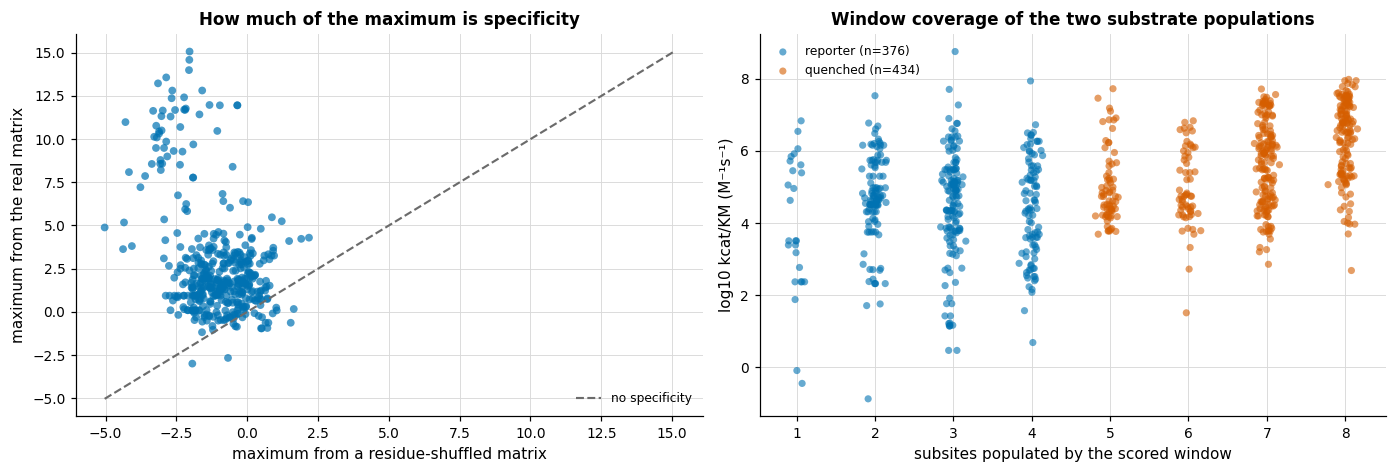

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4))

ax = axes[0]
ax.scatter(
    quenched["shuffled_score_mean"],
    quenched["merops_score"],
    s=26,
    color=common.CATEGORICAL_COLORS[0],
    alpha=0.7,
    edgecolor="none",
)
limits = [
    min(quenched["shuffled_score_mean"].min(), quenched["merops_score"].min()),
    max(quenched["shuffled_score_mean"].max(), quenched["merops_score"].max()),
]
ax.plot(limits, limits, color=common.NEUTRAL, linestyle="--", linewidth=1.4, label="no specificity")
ax.set_xlabel("maximum from a residue-shuffled matrix")
ax.set_ylabel("maximum from the real matrix")
ax.set_title("How much of the maximum is specificity")
ax.legend(fontsize=8)

ax = axes[1]
for index, convention in enumerate(["reporter", "quenched"]):
    subset = expanded[expanded["window_convention"] == convention]
    ax.scatter(
        subset["n_observed_subsites"] + generator.normal(0, 0.06, len(subset)),
        subset["log10_kcat_over_km"],
        s=22,
        alpha=0.6,
        color=common.CATEGORICAL_COLORS[index],
        edgecolor="none",
        label=f"{convention} (n={len(subset)})",
    )
ax.set_xlabel("subsites populated by the scored window")
ax.set_ylabel("log10 kcat/KM (M⁻¹s⁻¹)")
ax.set_title("Window coverage of the two substrate populations")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [11]:
common.save_result(recovery, f"{PREFIX}_site_recovery_validation.csv")
destination = common.save_result(expanded, f"{PREFIX}_substrate_table.csv")
print(f"written: {destination.relative_to(common.ROOT)}")
print()
print(f"The {SCOPE}-scope table is the input to the matching per-protease notebook, "
      "which splits it into training and held-out substrates.")
expanded.groupby(["window_convention", "merops_code"]).size().unstack(0).fillna(0).astype(int).head(15)

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/2_06_substrate_table.csv

The peptidase-scope table is the input to the matching per-protease notebook, which splits it into training and held-out substrates.


window_convention,quenched,reporter
merops_code,,
A01.009,55,0
A01.010,1,0
C01.009,9,2
C01.032,64,3
C01.034,0,5
C01.036,0,4
C01.060,1,3
C01.070,0,6
C02.001,0,6
